LOAD DATASET

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw_dataset.csv", encoding="latin1")

print("Shape:", df.shape)
print(df.head())
print(df["label"].value_counts())
print("\nPercentage distribution:\n")
print(df["label"].value_counts(normalize=True))
df["label"] = df["label"].str.strip()

Shape: (707, 3)
                       title  \
0             Reverse String   
1           Valid Palindrome   
2        Valid Palindrome II   
3    Valid Word Abbreviation   
4  Merge Strings Alternately   

                                         description         label  
0  You are given an array of characters which rep...  Two Pointers  
1  Given a string s, return true if it is a palin...  Two Pointers  
2  You are given a string s, return true if the s...  Two Pointers  
3  A string can be shortened by replacing any num...  Two Pointers  
4  You are given two strings, word1 and word2. Co...  Two Pointers  
label
Two Pointers           101
Sliding Window         101
Binary Search          101
Dynamic Programming    101
Graphs                 101
Greedy                 101
Heap/Priority Queue    101
Name: count, dtype: int64

Percentage distribution:

label
Two Pointers           0.142857
Sliding Window         0.142857
Binary Search          0.142857
Dynamic Programming    0.14

CLEAN TEXT

In [2]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = text.encode("ascii", "ignore").decode()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_description"] = df["description"].apply(clean_text)

In [3]:
print("Nulls in description:", df["clean_description"].isnull().sum())
print("Nulls in label:", df["label"].isnull().sum())
print(df[df["clean_description"].isnull()])


Nulls in description: 0
Nulls in label: 0
Empty DataFrame
Columns: [title, description, label, clean_description]
Index: []


In [4]:
df = df.dropna(subset=["clean_description", "label"])
print(df.isnull().sum())

title                0
description          0
label                0
clean_description    0
dtype: int64


TRAIN/TEST SPLIT

In [5]:
from sklearn.model_selection import train_test_split

X = df["clean_description"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 565
Test size: 142


MAJORITY BASELINE

In [6]:
from sklearn.metrics import accuracy_score

majority_class = y_train.value_counts().idxmax()
y_majority_pred = [majority_class] * len(y_test)

majority_accuracy = accuracy_score(y_test, y_majority_pred)

print("Majority class:", majority_class)
print("Majority baseline accuracy:", round(majority_accuracy, 3))

Majority class: Binary Search
Majority baseline accuracy: 0.141


TF-IDF

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    stop_words="english",
    max_features=8000,
    min_df=2              # ignore extremely rare words
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (565, 2480)


MODEL COMPARISION

In [8]:
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1500,
    class_weight="balanced",
    C=1.0
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [9]:
# LINEAR SVC
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

model = LinearSVC(class_weight="balanced")

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Linear SVM Accuracy:", round(accuracy, 3))

Linear SVM Accuracy: 0.711


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


FULL REPORT

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

                     precision    recall  f1-score   support

      Binary Search       0.87      0.65      0.74        20
Dynamic Programming       0.56      0.75      0.64        20
             Graphs       0.89      0.80      0.84        20
             Greedy       0.50      0.38      0.43        21
Heap/Priority Queue       0.85      0.85      0.85        20
     Sliding Window       0.75      0.75      0.75        20
       Two Pointers       0.65      0.81      0.72        21

           accuracy                           0.71       142
          macro avg       0.72      0.71      0.71       142
       weighted avg       0.72      0.71      0.71       142

[[13  0  0  3  2  2  0]
 [ 0 15  1  2  0  1  1]
 [ 0  2 16  1  0  0  1]
 [ 2  5  0  8  1  1  4]
 [ 0  1  0  0 17  1  1]
 [ 0  1  1  1  0 15  2]
 [ 0  3  0  1  0  0 17]]


In [11]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Improved Accuracy:", round(accuracy, 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Improved Accuracy: 0.711

Classification Report:

                     precision    recall  f1-score   support

      Binary Search       0.87      0.65      0.74        20
Dynamic Programming       0.56      0.75      0.64        20
             Graphs       0.89      0.80      0.84        20
             Greedy       0.50      0.38      0.43        21
Heap/Priority Queue       0.85      0.85      0.85        20
     Sliding Window       0.75      0.75      0.75        20
       Two Pointers       0.65      0.81      0.72        21

           accuracy                           0.71       142
          macro avg       0.72      0.71      0.71       142
       weighted avg       0.72      0.71      0.71       142



In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

for C_value in [0.1, 0.5, 1.0, 2.0, 5.0]:
    
    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        C=C_value
    )
    
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"C={C_value} → Accuracy={round(acc,3)}")

C=0.1 → Accuracy=0.556
C=0.5 → Accuracy=0.648
C=1.0 → Accuracy=0.669
C=2.0 → Accuracy=0.69
C=5.0 → Accuracy=0.718


Exploratory Data Analysis (EDA)

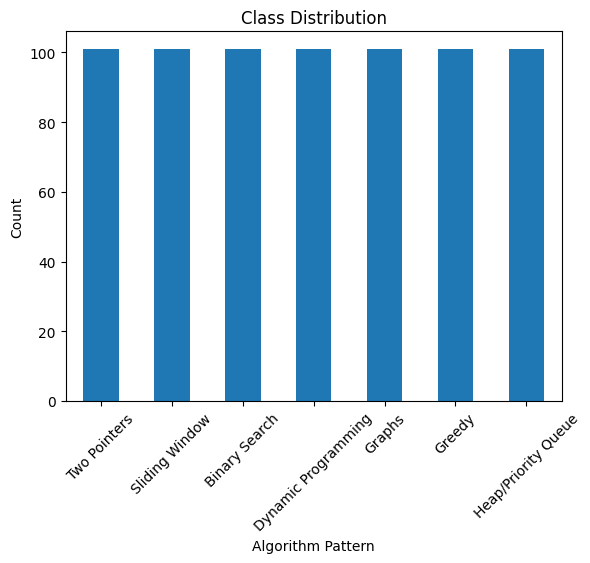

In [17]:
# CLASS DISTRIBUTION
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Algorithm Pattern")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The class distribution is balanced across all categories, which ensures that the model is not biased toward any particular algorithmic pattern.
This is important for multi-class classification tasks, as imbalanced datasets can lead to misleading accuracy where the model over-predicts dominant classes.

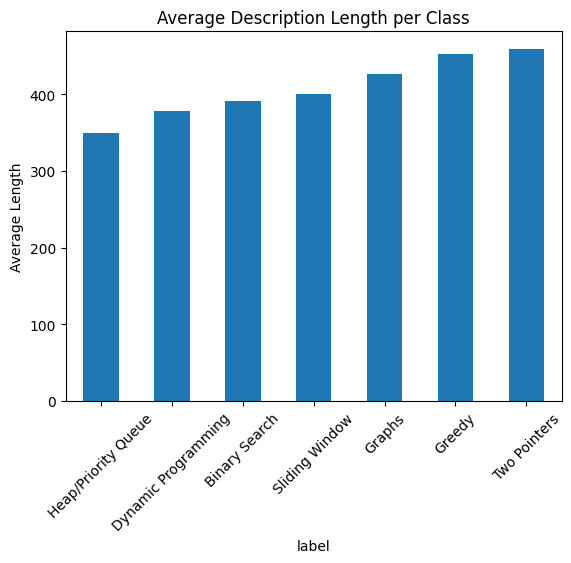

In [18]:
# TEXT LENGTH ANALYSIS
df["text_length"] = df["clean_description"].apply(len)

df.groupby("label")["text_length"].mean().sort_values().plot(kind="bar")

plt.title("Average Description Length per Class")
plt.ylabel("Average Length")
plt.xticks(rotation=45)
plt.show()

The average problem description length varies across algorithmic categories, with Two Pointers and Greedy problems tending to have longer descriptions, while Heap-related problems are comparatively shorter.

In [ ]:
# TOP WORDS PER CLASS
df["eda_text"] = df["description"].apply(clean_text)

In [ ]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

custom_stopwords = list(text.ENGLISH_STOP_WORDS)

custom_stopwords += [
    "example", "input", "output", "constraints",
    "given", "return", "explanation"
]

vectorizer = CountVectorizer(
    stop_words=custom_stopwords,
    max_features=1000
)

In [26]:
X_counts = vectorizer.fit_transform(df["eda_text"])

In [27]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

def get_top_words(label):
    indices = df[df["label"] == label].index
    counts = np.asarray(X_counts[indices].sum(axis=0)).flatten()
    top_indices = counts.argsort()[-10:][::-1]
    return [feature_names[i] for i in top_indices]

for label in df["label"].unique():
    print(f"\nTop words for {label}:")
    print(get_top_words(label))


Top words for Two Pointers:
['nums', 'array', 'length', 'string', 'elements', '10', 'integer', 'true', '000', 'characters']

Top words for Sliding Window:
['nums', 'length', 'array', 'integer', 'subarray', 'number', '100000', 'maximum', 'string', 'longest']

Top words for Binary Search:
['nums', 'length', 'array', 'target', '100000', 'integer', '10', 'sorted', 'index', 'maximum']

Top words for Dynamic Programming:
['nums', 'length', 'number', '10', 'array', 'integer', 'maximum', '1000', 'points', 'minimum']

Top words for Graphs:
['grid', 'length', 'graph', 'edges', 'node', 'course', 'number', 'time', 'person', 'board']

Top words for Greedy:
['nums', 'length', 'array', 'minimum', 'string', 'integer', 'maximum', 'number', 'subarray', 'score']

Top words for Heap/Priority Queue:
['10', 'length', 'nums', 'array', 'integer', 'time', 'grid', 'number', 'minimum', 'sum']


Graph-related problems are associated with terms like "node", "edge", and "graph", while Sliding Window problems frequently contain words like "substring" and "window".

This explains why certain classes are easier for the model to classify.

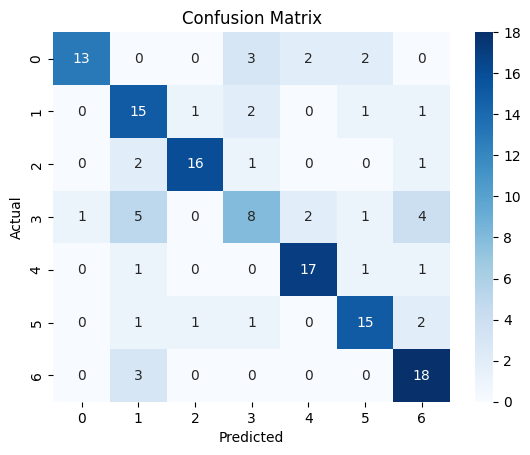

In [20]:
# CONFUSION MATRIX ANALYSIS
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix highlights that while the model performs well for classes with distinctive lexical patterns, it struggles with conceptually similar categories such as Greedy and Dynamic Programming. This reinforces the limitation of TF-IDF representations in capturing deeper semantic differences between algorithmic strategies.

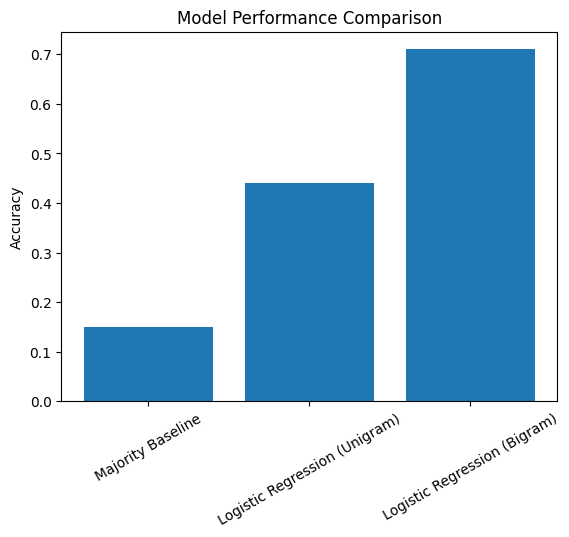

In [21]:
# MODEL PERFORMANCE COMPARISON
models = ["Majority Baseline", "Logistic Regression (Unigram)", "Logistic Regression (Bigram)"]
accuracy = [0.15, 0.44, 0.71]  # update with your real values

plt.bar(models, accuracy)
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

The experiment shows that classical NLP techniques, when combined with sufficient data and feature engineering, can achieve strong performance in multi-class classification tasks. However, the observed performance gap between classes indicates that deeper semantic understanding is still required for complete pattern separation.